# Python for Data Science – DSA 2026 Summer School
## Plenary Session (2 Hours) — Data Preprocessing

**Instructors:** TCHAPGA Tchito Christian (UB/COT) & Elhoussaine Gangouch (UM6P)   
**Event:** Data Science Africa Summer School · July 20–24, 2026 · Kampala, Uganda  
**Platform:** Google Colab · [datascienceafrica.org](https://www.datascienceafrica.org)

---

### Session Roadmap

| Time | Topic | Library |
|------|-------|---------|
| 0–20 min | Array Computing & Statistical Ops | **NumPy** |
| 20–45 min | Data Wrangling & Feature Engineering | **Pandas** |
| 45–60 min | Statistical Analysis & Outlier Detection | **SciPy** |
| 60–80 min | Exploratory Visualisation | **Matplotlib / Seaborn** |
| 80–110 min | End-to-End Preprocessing Pipeline | All libraries |
| 110–120 min | Wrap-Up & Q&A | — |

> **Learning Outcomes:** By the end of this session you will be able to clean, transform, visualise, and prepare a raw dataset for a machine-learning workflow using Python's core data science stack.

In [5]:
# ── Setup (run once) ──────────────────────────────────────────────────────────
# Uncomment the line below if running on Google Colab
# !pip install -q seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore, shapiro, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style throughout the notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 4)

print('✓ NumPy   ', np.__version__)
print('✓ Pandas  ', pd.__version__)
print('✓ Seaborn ', sns.__version__)
print('All libraries loaded!')

✓ NumPy    2.1.3
✓ Pandas   3.0.2
✓ Seaborn  0.13.2
All libraries loaded!


---
## Part 1 — NumPy: Array Computing & Statistical Operations

NumPy is the foundation of the scientific Python stack. Nearly every data science library stores data internally as NumPy arrays. Understanding it makes everything else faster and cleaner.

In [42]:
# 1.1  Array creation ─────────────────────────────────────────────────────────
a = np.array([2.5, 3.1, 4.7, 1.9, 5.0, 3.8, 2.2])   # from a list
b = np.arange(0, 10, 2)                               # [0, 2, 4, 6, 8]
c = np.linspace(0, 1, 5)                              # 5 evenly spaced values in [0,1]
zeros = np.zeros((2,3,4))                              # 3×4 matrix of zeros
rand  = np.random.seed(42); rand = np.random.randn(100) # 100 standard-normal samples

print('1-D array a:', a)
print('arange   b:', b)
print('linspace c:', c)
print('zeros shape:', zeros.shape)
print('rand numbers:', rand)

1-D array a: [2.5 3.1 4.7 1.9 5.  3.8 2.2]
arange   b: [0 2 4 6 8]
linspace c: [0.   0.25 0.5  0.75 1.  ]
zeros shape: (2, 3, 4)
rand numbers: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004 -0.46341769 -0.46572975
  0.24196227 -1.91328024 -1.72491783 -0.56228753 -1.01283112  0.31424733
 -0.90802408 -1.4123037   1.46564877 -0.2257763   0.0675282  -1.42474819
 -0.54438272  0.11092259 -1.15099358  0.37569802 -0.60063869 -0.29169375
 -0.60170661  1.85227818 -0.01349722 -1.05771093  0.82254491 -1.22084365
  0.2088636  -1.95967012 -1.32818605  0.19686124  0.73846658  0.17136828
 -0.11564828 -0.3011037  -1.47852199 -0.71984421 -0.46063877  1.05712223
  0.34361829 -1.76304016  0.32408397 -0.38508228 -0.676922    0.61167629
  1.03099952  0.93128012 -0.83921752 -0.30921238  0.33126343  0.97554513
 -0.47917424 -0.18565898 -1.10633497 -1.19620662  0.81252582  1.35624003
 -0.07201012  1.0035329   0.36163603 -0.64511975  0.36

In [7]:
# 1.2  Vectorised operations (no Python loops needed) ─────────────────────────
temperatures = np.array([36.5, 37.1, 38.4, 36.8, 39.2, 37.5, 38.0, 36.9])

# Convert Celsius → Fahrenheit in one line
temp_f = temperatures * 9/5 + 32
print('Celsius  :', temperatures)
print('Fahrenheit:', np.round(temp_f, 1))

# Boolean masking — select patients with fever (>37.5 °C)
fever_mask = temperatures > 37.5
print('\nFever mask        :', fever_mask)
print('Fever temperatures:', temperatures[fever_mask])

Celsius  : [36.5 37.1 38.4 36.8 39.2 37.5 38.  36.9]
Fahrenheit: [ 97.7  98.8 101.1  98.2 102.6  99.5 100.4  98.4]

Fever mask        : [False False  True False  True False  True False]
Fever temperatures: [38.4 39.2 38. ]


In [8]:
# 1.3  Descriptive statistics in NumPy ────────────────────────────────────────
np.random.seed(0)
glucose = np.random.normal(loc=100, scale=15, size=200)  # mg/dL, normal population

print(f'Count  : {len(glucose)}')
print(f'Mean   : {glucose.mean():.2f}')
print(f'Median : {np.median(glucose):.2f}')
print(f'Std Dev: {glucose.std():.2f}')
print(f'Min/Max: {glucose.min():.2f} / {glucose.max():.2f}')
print(f'25th / 75th percentile: {np.percentile(glucose, 25):.2f} / {np.percentile(glucose, 75):.2f}')

Count  : 200
Mean   : 101.06
Median : 100.81
Std Dev: 15.32
Min/Max: 61.71 / 135.75
25th / 75th percentile: 89.41 / 112.12


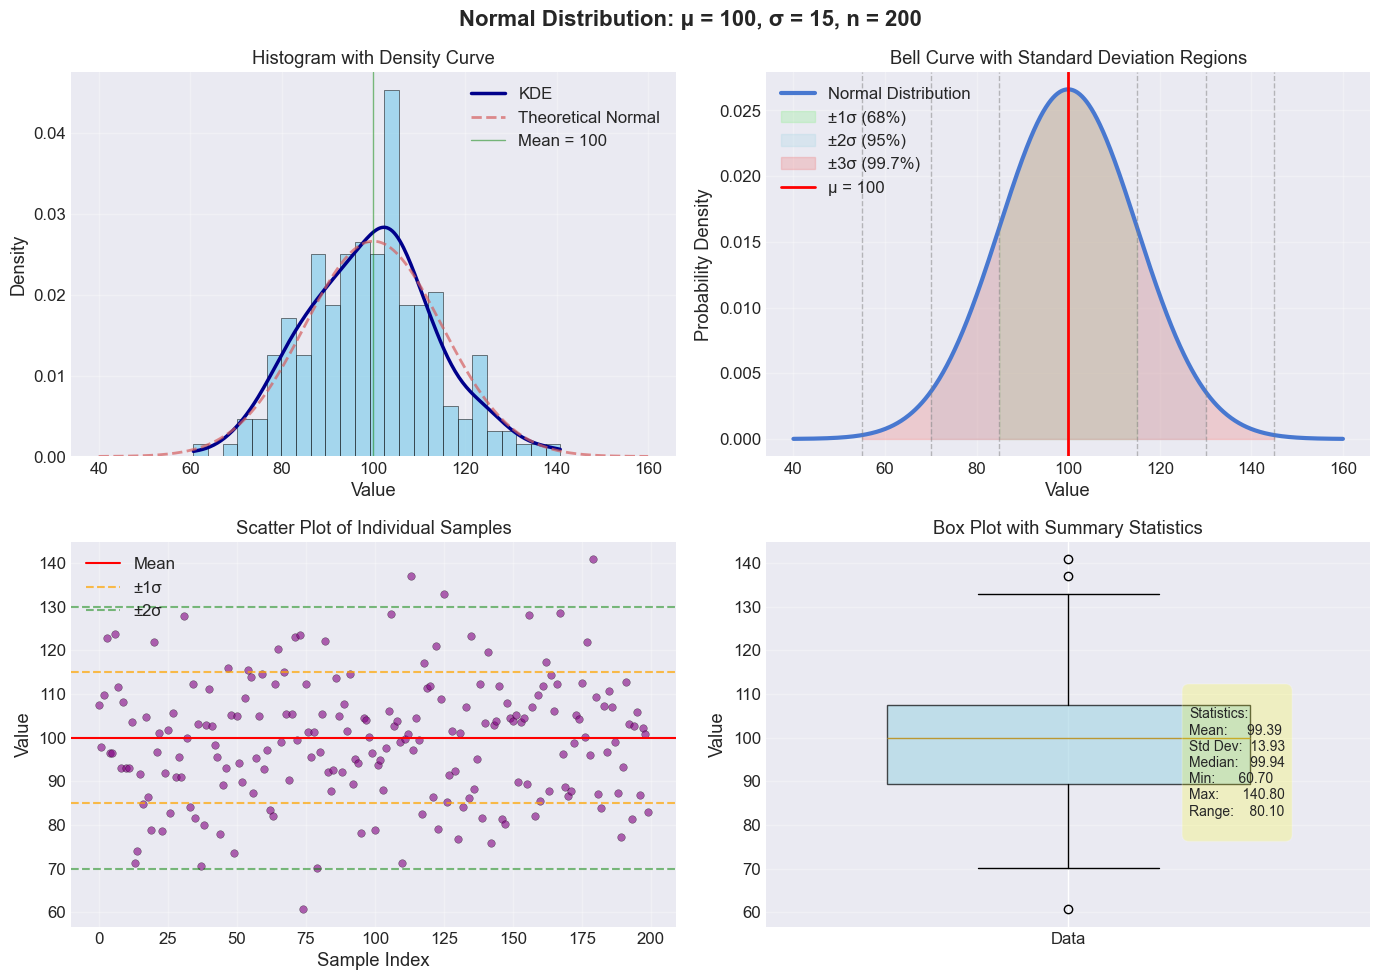

DETAILED STATISTICS
Mean:          99.39
Median:        99.94
Std Dev:       13.93
Variance:      194.05
Min:           60.70
Max:           140.80
Range:         80.10
Q1 (25th):     89.42
Q3 (75th):     107.51
IQR:           18.09

PERCENTAGE OF DATA IN RANGES
Within ±1σ (85-115):  72.5%
Within ±2σ (70-130):  98.0%
Within ±3σ (55-145):  100.0%

NORMALITY TEST (Shapiro-Wilk)
Statistic:     0.9956
P-value:       0.8290
✓ Data appears to be normally distributed (fail to reject H₀)


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generate the data
np.random.seed(42)  # For reproducibility
data = np.random.normal(loc=100, scale=15, size=200)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Normal Distribution: μ = 100, σ = 15, n = 200', fontsize=16, fontweight='bold')

# --- Plot 1: Histogram with KDE ---
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(data, bins=25, density=True, alpha=0.7, color='skyblue', 
                           edgecolor='black', linewidth=0.5)
# Overlay KDE
kde = stats.gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 200)
ax1.plot(x_range, kde(x_range), color='darkblue', linewidth=2.5, label='KDE')

# Add theoretical normal curve
x_theory = np.linspace(40, 160, 1000)
y_theory = stats.norm.pdf(x_theory, loc=100, scale=15)
ax1.plot(x_theory, y_theory, 'r--', linewidth=2, label='Theoretical Normal', alpha=0.7)

ax1.axvline(100, color='green', linestyle='-', linewidth=1, alpha=0.5, label='Mean = 100')
ax1.set_xlabel('Value')
ax1.set_ylabel('Density')
ax1.set_title('Histogram with Density Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Bell Curve with Key Markers ---
ax2 = axes[0, 1]
x = np.linspace(40, 160, 1000)
y = stats.norm.pdf(x, loc=100, scale=15)

ax2.plot(x, y, 'b-', linewidth=3, label='Normal Distribution')

# Highlight standard deviation regions
colors = ['lightgreen', 'lightblue', 'lightcoral']
labels = ['±1σ (68%)', '±2σ (95%)', '±3σ (99.7%)']
sigmas = [1, 2, 3]

for i, sigma in enumerate(sigmas):
    x_fill = np.linspace(100 - sigma*15, 100 + sigma*15, 100)
    y_fill = stats.norm.pdf(x_fill, loc=100, scale=15)
    ax2.fill_between(x_fill, y_fill, alpha=0.3, color=colors[i], label=labels[i])

# Mark mean and standard deviation points
ax2.axvline(100, color='red', linestyle='-', linewidth=2, label='μ = 100')
for sigma in sigmas:
    ax2.axvline(100 + sigma*15, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax2.axvline(100 - sigma*15, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax2.set_xlabel('Value')
ax2.set_ylabel('Probability Density')
ax2.set_title('Bell Curve with Standard Deviation Regions')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# --- Plot 3: Scatter Plot of Data ---
ax3 = axes[1, 0]
x_positions = np.arange(len(data))
ax3.scatter(x_positions, data, alpha=0.6, s=30, color='purple', 
           edgecolors='black', linewidth=0.3)
ax3.axhline(100, color='red', linestyle='-', linewidth=1.5, label='Mean')
ax3.axhline(100 + 15, color='orange', linestyle='--', alpha=0.7, label='±1σ')
ax3.axhline(100 - 15, color='orange', linestyle='--', alpha=0.7)
ax3.axhline(100 + 30, color='green', linestyle='--', alpha=0.5, label='±2σ')
ax3.axhline(100 - 30, color='green', linestyle='--', alpha=0.5)
ax3.set_xlabel('Sample Index')
ax3.set_ylabel('Value')
ax3.set_title('Scatter Plot of Individual Samples')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Box Plot and Statistics ---
ax4 = axes[1, 1]

# Box plot
bp = ax4.boxplot(data, vert=True, patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

# Add statistics text
stats_text = f"""
Statistics:
Mean:     {np.mean(data):.2f}
Std Dev:  {np.std(data):.2f}
Median:   {np.median(data):.2f}
Min:      {np.min(data):.2f}
Max:      {np.max(data):.2f}
Range:    {np.max(data) - np.min(data):.2f}
"""
ax4.text(1.2, np.percentile(data, 5), stats_text, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor='yellow', alpha=0.2),
         fontsize=10, verticalalignment='bottom')

ax4.set_xticklabels(['Data'])
ax4.set_ylabel('Value')
ax4.set_title('Box Plot with Summary Statistics')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 50)
print("DETAILED STATISTICS")
print("=" * 50)
print(f"Mean:          {np.mean(data):.2f}")
print(f"Median:        {np.median(data):.2f}")
#print(f"Mode:          {stats.mode(np.round(data, 0))[0][0]:.0f} (approx)")
print(f"Std Dev:       {np.std(data):.2f}")
print(f"Variance:      {np.var(data):.2f}")
print(f"Min:           {np.min(data):.2f}")
print(f"Max:           {np.max(data):.2f}")
print(f"Range:         {np.max(data) - np.min(data):.2f}")
print(f"Q1 (25th):     {np.percentile(data, 25):.2f}")
print(f"Q3 (75th):     {np.percentile(data, 75):.2f}")
print(f"IQR:           {np.percentile(data, 75) - np.percentile(data, 25):.2f}")

print("\n" + "=" * 50)
print("PERCENTAGE OF DATA IN RANGES")
print("=" * 50)
print(f"Within ±1σ (85-115):  {((data >= 85) & (data <= 115)).mean()*100:.1f}%")
print(f"Within ±2σ (70-130):  {((data >= 70) & (data <= 130)).mean()*100:.1f}%")
print(f"Within ±3σ (55-145):  {((data >= 55) & (data <= 145)).mean()*100:.1f}%")

# Hypothesis test for normality
from scipy import stats
stat, p_value = stats.shapiro(data)
print("\n" + "=" * 50)
print("NORMALITY TEST (Shapiro-Wilk)")
print("=" * 50)
print(f"Statistic:     {stat:.4f}")
print(f"P-value:       {p_value:.4f}")
if p_value > 0.05:
    print("✓ Data appears to be normally distributed (fail to reject H₀)")
else:
    print("✗ Data may NOT be normally distributed (reject H₀)")

In [9]:
# 1.4  Handling NaN values ────────────────────────────────────────────────────
data_with_nan = np.array([5.1, np.nan, 3.4, np.nan, 7.8, 6.2, np.nan, 4.5])

print('Original array  :', data_with_nan)
print('NaN positions   :', np.isnan(data_with_nan))
print('NaN count       :', np.sum(np.isnan(data_with_nan)))

# Safe statistics that ignore NaN
print('Mean (with NaN) :', np.mean(data_with_nan))       # returns nan !
print('Mean (nan-safe) :', np.nanmean(data_with_nan))    # ignores NaN

# Simple imputation: replace NaN with the column mean
filled = np.where(np.isnan(data_with_nan), np.nanmean(data_with_nan), data_with_nan)
print('After imputation:', np.round(filled, 2))

Original array  : [5.1 nan 3.4 nan 7.8 6.2 nan 4.5]
NaN positions   : [False  True False  True False False  True False]
NaN count       : 3
Mean (with NaN) : nan
Mean (nan-safe) : 5.4
After imputation: [5.1 5.4 3.4 5.4 7.8 6.2 5.4 4.5]


In [10]:
# 1.5  Reshaping & broadcasting (critical for ML pipelines) ───────────────────
features = np.array([170, 65, 36.8, 120])  # height(cm), weight(kg), temp(°C), BP(mmHg)

# Reshape a 1-D vector to a 2-D row (1 sample × 4 features) for sklearn
X_single = features.reshape(1, -1)
print('Shape for sklearn:', X_single.shape)   # (1, 4)

# Broadcasting: subtract mean and divide by std (manual z-score normalisation)
X = np.random.randn(5, 4) * [10, 5, 1, 20] + [165, 70, 37, 110]  # 5 patients
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
print('\nRaw data (5 patients):\n', np.round(X, 1))
print('\nZ-score normalised:\n', np.round(X_norm, 2))

Shape for sklearn: (1, 4)

Raw data (5 patients):
 [[161.3  68.8  38.1 123.1]
 [171.4  61.9  37.   95.2]
 [167.8  69.5  37.9 116.3]
 [172.9  67.7  36.1 101.8]
 [164.8  71.9  39.3 109.2]]

Z-score normalised:
 [[-1.5   0.25  0.41  1.41]
 [ 0.89 -1.82 -0.63 -1.4 ]
 [ 0.04  0.47  0.23  0.73]
 [ 1.23 -0.09 -1.48 -0.74]
 [-0.66  1.18  1.48  0.  ]]


### ✏️ Try It Yourself
1. Create a NumPy array of 50 random integers between 0 and 100 (hint: `np.random.randint`).  
2. Compute the mean, median, and standard deviation.  
3. Replace all values above 80 with `np.nan`, then recompute the mean safely with `np.nanmean`.

In [11]:
# Your code here


---
## Part 2 — Pandas: Data Wrangling & Feature Engineering

Pandas wraps NumPy arrays in labelled tables (DataFrames) and adds powerful data-manipulation tools. Most preprocessing work lives here.

In [46]:
# 2.1  Load & first look ──────────────────────────────────────────────────────
# We use the WHO life-expectancy dataset — publicly available
url = 'https://github.com/EvidenceN/DataSets/blob/master/Life%20Expectancy%20Data.csv'
try:
    df = pd.read_csv(url)
    print('Loaded from URL.')
except Exception:
    # Fallback: create a comparable synthetic dataset
    np.random.seed(42)
    n = 200
    df = pd.DataFrame({
        'Country'          : np.random.choice(['Nigeria','Kenya','Ethiopia','Ghana','Uganda','Egypt','Morocco'], n),
        'Year'             : np.random.randint(2000, 2016, n),
        'Status'           : np.random.choice(['Developed','Developing'], n, p=[0.15, 0.85]),
        'Life expectancy'  : np.random.normal(63, 9, n),
        'Adult Mortality'  : np.random.normal(180, 70, n),
        'infant deaths'    : np.random.randint(0, 60, n).astype(float),
        'Alcohol'          : np.random.exponential(2, n),
        'GDP'              : np.random.exponential(3000, n),
        'Population'       : np.random.exponential(2e7, n),
        'BMI'              : np.random.normal(24, 5, n),
        'Schooling'        : np.random.normal(10, 3, n),
    })
    # Inject realistic missing values
    for col in ['GDP', 'Population', 'BMI', 'Alcohol', 'Schooling']:
        mask = np.random.choice([True, False], n, p=[0.12, 0.88])
        df.loc[mask, col] = np.nan
    print('Using synthetic fallback dataset.')

print(f'Shape: {df.shape}')
df.head()

Using synthetic fallback dataset.
Shape: (200, 11)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,GDP,Population,BMI,Schooling
0,Morocco,2013,Developing,55.320661,214.760471,57.0,5.164497,1698.670418,8.492347e+05,NaN,9.584632
1,Ghana,2008,Developed,62.871475,166.402403,21.0,7.084940,8626.705298,3.211433e+06,24.380027,NaN
2,Uganda,2004,Developing,64.817167,165.563273,43.0,5.774347,1632.771428,8.629502e+07,NaN,9.372930
3,Morocco,2005,Developing,55.757370,20.543471,23.0,1.285723,3052.695053,6.711609e+07,19.396632,7.448439
4,Ethiopia,2011,Developing,50.034125,235.823894,16.0,3.961621,1520.472909,9.904446e+04,24.846804,8.258430


In [48]:
# 2.2  Data profiling: types, nulls, cardinality ──────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Value Summary ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})[missing > 0])
print('\n=== Numerical Summary ===')
df.describe().round(2)

=== Data Types ===
Country                str
Year                 int64
Status                 str
Life expectancy    float64
Adult Mortality    float64
infant deaths      float64
Alcohol            float64
GDP                float64
Population         float64
BMI                float64
Schooling          float64
dtype: object

=== Missing Value Summary ===
            Missing  Pct (%)
Alcohol          23     11.5
GDP              31     15.5
Population       18      9.0
BMI              32     16.0
Schooling        26     13.0

=== Numerical Summary ===


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,GDP,Population,BMI,Schooling
count,200.00,200.00,200.00,200.0,177.00,169.00,1.820000e+02,168.00,174.00
mean,2007.18,63.02,186.89,30.6,2.24,2832.45,2.046003e+07,24.56,10.10
std,4.81,9.59,78.63,16.7,2.14,2904.42,2.143852e+07,5.01,3.11
min,2000.00,31.70,-69.77,0.0,0.01,29.46,9.904446e+04,11.04,1.24
25%,2003.00,56.45,137.31,16.0,0.62,691.42,5.667795e+06,20.97,8.09
50%,2007.00,63.43,190.80,31.0,1.75,1961.43,1.537424e+07,24.63,9.96
75%,2011.00,68.83,236.61,44.0,3.17,3810.36,2.526290e+07,27.72,12.09
max,2015.00,86.16,402.21,59.0,11.70,16825.89,1.488345e+08,37.01,19.58


In [14]:
# 2.3  Handling missing values ────────────────────────────────────────────────
df_clean = df.copy()

# Strategy A: Drop rows missing the target variable
target_col = 'Life expectancy'
before = len(df_clean)
df_clean.dropna(subset=[target_col], inplace=True)
print(f'Rows dropped (missing target): {before - len(df_clean)}')

# Strategy B: Impute numeric columns with the median (robust to outliers)
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
numeric_cols.remove(target_col)  # don't impute the target

for col in numeric_cols:
    median_val = df_clean[col].median()
    n_filled = df_clean[col].isna().sum()
    df_clean[col].fillna(median_val, inplace=True)
    if n_filled:
        print(f'  Imputed {n_filled:3d} missing in "{col}" with median = {median_val:.2f}')

# Strategy C: Impute categorical columns with the mode
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    n_filled = df_clean[col].isna().sum()
    df_clean[col].fillna(mode_val, inplace=True)
    if n_filled:
        print(f'  Imputed {n_filled:3d} missing in "{col}" with mode = "{mode_val}"')

print(f'\nRemaining NaNs: {df_clean.isnull().sum().sum()}')

Rows dropped (missing target): 0
  Imputed  23 missing in "Alcohol" with median = 1.75
  Imputed  31 missing in "GDP" with median = 1961.43
  Imputed  18 missing in "Population" with median = 15374242.42
  Imputed  32 missing in "BMI" with median = 24.63
  Imputed  26 missing in "Schooling" with median = 9.96

Remaining NaNs: 130


In [15]:
# 2.4  Data type conversions & column renaming ────────────────────────────────
# Standardise column names: lowercase, replace spaces with underscores
df_clean.columns = [c.strip().lower().replace(' ', '_') for c in df_clean.columns]
print('Renamed columns:', df_clean.columns.tolist())

# Ensure 'year' is integer
df_clean['year'] = df_clean['year'].astype(int)

# Encode 'status' as a binary indicator (common preprocessing step)
df_clean['is_developing'] = (df_clean['status'] == 'Developing').astype(int)
print('\nStatus encoding sample:')
df_clean[['status', 'is_developing']].value_counts()

Renamed columns: ['country', 'year', 'status', 'life_expectancy', 'adult_mortality', 'infant_deaths', 'alcohol', 'gdp', 'population', 'bmi', 'schooling']

Status encoding sample:


status      is_developing
Developing  1                170
Developed   0                 30
Name: count, dtype: int64

In [16]:
# 2.5  Filtering, sorting & groupBy ──────────────────────────────────────────
# Filter: recent years only
recent = df_clean[df_clean['year'] >= 2010]
print(f'Records from 2010+: {len(recent)}')

# GroupBy: average life expectancy by status
grp = df_clean.groupby('status')['life_expectancy'].agg(['mean','std','count']).round(2)
print('\nLife expectancy by development status:')
print(grp)

# Country ranking (if Country column exists)
if 'country' in df_clean.columns:
    top = df_clean.groupby('country')['life_expectancy'].mean().sort_values(ascending=False)
    print('\nTop 5 countries by mean life expectancy:')
    print(top.head())

Records from 2010+: 71

Life expectancy by development status:
             mean    std  count
status                         
Developed   65.58  10.63     30
Developing  62.57   9.35    170

Top 5 countries by mean life expectancy:
country
Nigeria     65.761433
Ethiopia    65.399138
Kenya       63.361745
Uganda      63.334994
Egypt       62.522526
Name: life_expectancy, dtype: float64


In [17]:
# 2.6  Feature engineering ────────────────────────────────────────────────────
# Log-transform skewed features (reduces the effect of extreme values)
for col in ['gdp', 'population']:
    if col in df_clean.columns:
        df_clean[f'{col}_log'] = np.log1p(df_clean[col])   # log(1+x) handles zeros
        print(f'{col} skewness:  before={df_clean[col].skew():.2f}  after={df_clean[f"{col}_log"].skew():.2f}')

# Binning: discretise life expectancy into low / medium / high
bins   = [0, 55, 70, 100]
labels = ['Low (<55)', 'Medium (55–70)', 'High (>70)']
df_clean['le_category'] = pd.cut(df_clean['life_expectancy'], bins=bins, labels=labels)
print('\nLife expectancy categories:')
print(df_clean['le_category'].value_counts())

gdp skewness:  before=1.86  after=-0.69
population skewness:  before=2.43  after=-1.08

Life expectancy categories:
le_category
Medium (55–70)    117
High (>70)         46
Low (<55)          37
Name: count, dtype: int64


### ✏️ Try It Yourself
1. Check how many unique countries (or years) are in `df_clean`.  
2. Calculate the average `bmi` grouped by `le_category`.  
3. Create a new column `high_mortality` that is `1` when `adult_mortality > 200` and `0` otherwise.

In [18]:
# Your code here


---
## Part 3 — SciPy: Statistical Analysis & Outlier Detection

SciPy builds on NumPy with algorithms for statistics, optimisation, and signal processing. In preprocessing we use it for hypothesis testing, outlier detection, and distribution analysis.

In [19]:
# 3.1  Test for normality (Shapiro-Wilk) ─────────────────────────────────────
le_vals = df_clean['life_expectancy'].dropna().values

# Use a sample of 200 (Shapiro-Wilk works best on small-to-medium samples)
sample = le_vals[:200] if len(le_vals) > 200 else le_vals
stat, p_value = shapiro(sample)

print(f'Shapiro-Wilk statistic : {stat:.4f}')
print(f'p-value                : {p_value:.4f}')
if p_value > 0.05:
    print('Conclusion: data appears NORMALLY distributed (fail to reject H₀)')
else:
    print('Conclusion: data does NOT appear normally distributed (reject H₀)')
    print('→ Prefer median imputation and non-parametric methods')

Shapiro-Wilk statistic : 0.9951
p-value                : 0.7580
Conclusion: data appears NORMALLY distributed (fail to reject H₀)


EXAMPLE 1: Large Effect
------------------------------------------------------------
P-VALUE EXPLANATION
Sample size:        50
Sample mean:        10.98
Population mean:    0
Sample std dev:     2.86
Standard error:     0.40
T-statistic:        27.1837
P-value:            0.0000
------------------------------------------------------------
✅ STATISTICALLY SIGNIFICANT
→ There is a 0.00% chance of seeing this data
  if the true mean is actually 0
→ This is very unlikely (less than 5%)
→ We REJECT the null hypothesis
→ Conclude: Mean is DIFFERENT from 0


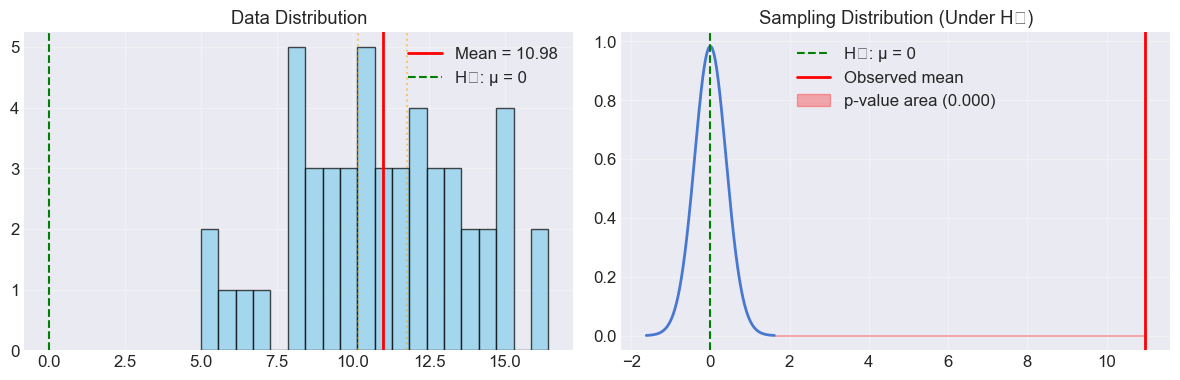


EXAMPLE 2: No Effect
------------------------------------------------------------
P-VALUE EXPLANATION
Sample size:        50
Sample mean:        0.18
Population mean:    0
Sample std dev:     2.78
Standard error:     0.39
T-statistic:        0.4562
P-value:            0.6502
------------------------------------------------------------
❌ NOT STATISTICALLY SIGNIFICANT
→ There is a 65.02% chance of seeing this data
  if the true mean is actually 0
→ This could easily happen by random chance
→ We FAIL to reject the null hypothesis
→ Conclude: No evidence mean differs from 0


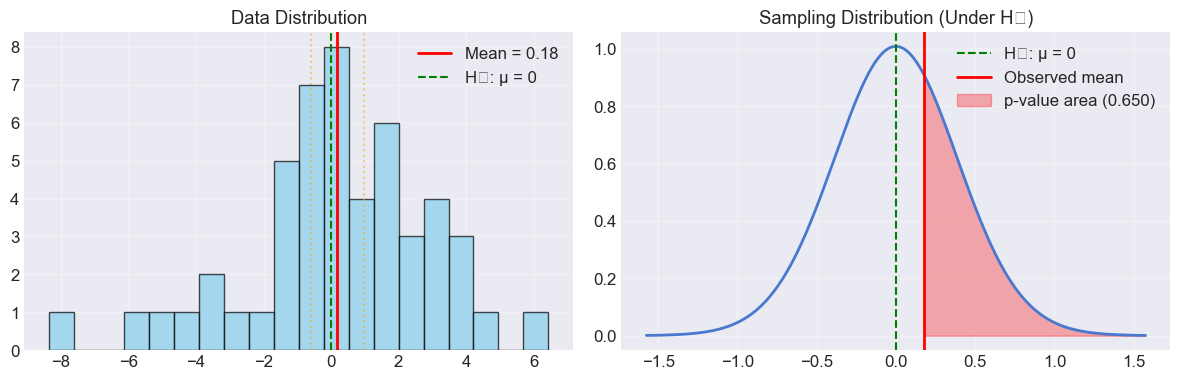


EXAMPLE 3: Borderline Effect
------------------------------------------------------------
P-VALUE EXPLANATION
Sample size:        50
Sample mean:        1.55
Population mean:    0
Sample std dev:     3.10
Standard error:     0.44
T-statistic:        3.5339
P-value:            0.0009
------------------------------------------------------------
✅ STATISTICALLY SIGNIFICANT
→ There is a 0.09% chance of seeing this data
  if the true mean is actually 0
→ This is very unlikely (less than 5%)
→ We REJECT the null hypothesis
→ Conclude: Mean is DIFFERENT from 0


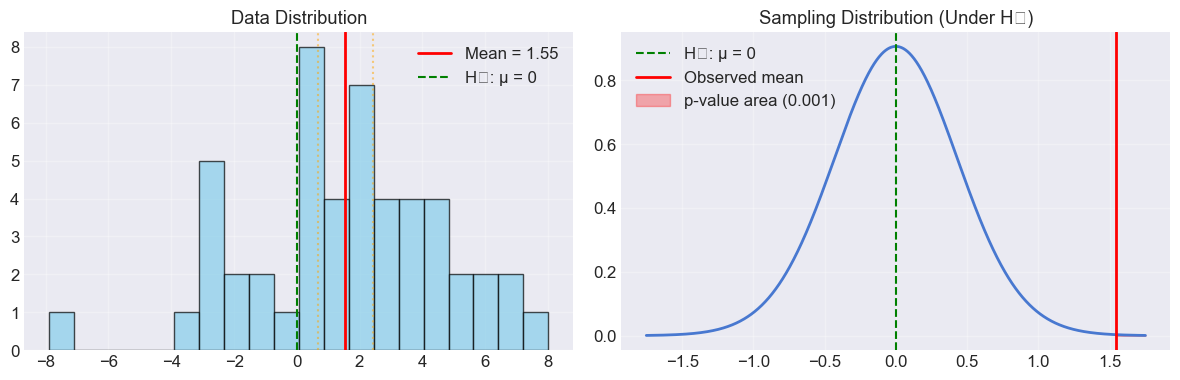

In [50]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def explain_p_value(data, population_mean=0):
    """
    Calculate and explain p-value for a one-sample t-test
    """
    # Perform t-test
    t_stat, p_value = stats.ttest_1samp(data, population_mean)
    
    # Calculate statistics
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    n = len(data)
    se = sample_std / np.sqrt(n)  # Standard error
    
    print("=" * 60)
    print("P-VALUE EXPLANATION")
    print("=" * 60)
    print(f"Sample size:        {n}")
    print(f"Sample mean:        {sample_mean:.2f}")
    print(f"Population mean:    {population_mean}")
    print(f"Sample std dev:     {sample_std:.2f}")
    print(f"Standard error:     {se:.2f}")
    print(f"T-statistic:        {t_stat:.4f}")
    print(f"P-value:            {p_value:.4f}")
    print("-" * 60)
    
    # Interpretation
    if p_value < 0.05:
        print("✅ STATISTICALLY SIGNIFICANT")
        print(f"→ There is a {p_value*100:.2f}% chance of seeing this data")
        print(f"  if the true mean is actually {population_mean}")
        print("→ This is very unlikely (less than 5%)")
        print("→ We REJECT the null hypothesis")
        print(f"→ Conclude: Mean is DIFFERENT from {population_mean}")
    else:
        print("❌ NOT STATISTICALLY SIGNIFICANT")
        print(f"→ There is a {p_value*100:.2f}% chance of seeing this data")
        print(f"  if the true mean is actually {population_mean}")
        print("→ This could easily happen by random chance")
        print("→ We FAIL to reject the null hypothesis")
        print(f"→ Conclude: No evidence mean differs from {population_mean}")
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    ax1.hist(data, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(sample_mean, color='red', linewidth=2, label=f'Mean = {sample_mean:.2f}')
    ax1.axvline(population_mean, color='green', linestyle='--', 
                label=f'H₀: μ = {population_mean}')
    ax1.axvline(sample_mean - 2*se, color='orange', linestyle=':', alpha=0.5)
    ax1.axvline(sample_mean + 2*se, color='orange', linestyle=':', alpha=0.5)
    ax1.set_title('Data Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Sampling distribution
    x = np.linspace(population_mean - 4*se, population_mean + 4*se, 1000)
    y = stats.t.pdf(x, n-1, loc=population_mean, scale=se)
    ax2.plot(x, y, 'b-', linewidth=2)
    ax2.axvline(population_mean, color='green', linestyle='--', 
                label=f'H₀: μ = {population_mean}')
    ax2.axvline(sample_mean, color='red', linewidth=2, label=f'Observed mean')
    
    # Shade the tail (p-value area)
    if sample_mean > population_mean:
        x_tail = np.linspace(sample_mean, population_mean + 4*se, 100)
        y_tail = stats.t.pdf(x_tail, n-1, loc=population_mean, scale=se)
        ax2.fill_between(x_tail, y_tail, alpha=0.3, color='red', 
                         label=f'p-value area ({p_value:.3f})')
    else:
        x_tail = np.linspace(population_mean - 4*se, sample_mean, 100)
        y_tail = stats.t.pdf(x_tail, n-1, loc=population_mean, scale=se)
        ax2.fill_between(x_tail, y_tail, alpha=0.3, color='red',
                         label=f'p-value area ({p_value:.3f})')
    
    ax2.set_title('Sampling Distribution (Under H₀)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return p_value

# --- Examples ---

# Example 1: Clear effect (small p-value)
print("EXAMPLE 1: Large Effect")
print("-" * 60)
data1 = np.random.normal(10, 3, 50)  # Mean = 10
p1 = explain_p_value(data1, population_mean=0)

# Example 2: No effect (large p-value)
print("\n" + "EXAMPLE 2: No Effect")
print("-" * 60)
data2 = np.random.normal(0.2, 3, 50)  # Mean ≈ 0
p2 = explain_p_value(data2, population_mean=0)

# Example 3: Borderline effect
print("\n" + "EXAMPLE 3: Borderline Effect")
print("-" * 60)
data3 = np.random.normal(0.8, 3, 50)  # Mean ≈ 0.8
p3 = explain_p_value(data3, population_mean=0)

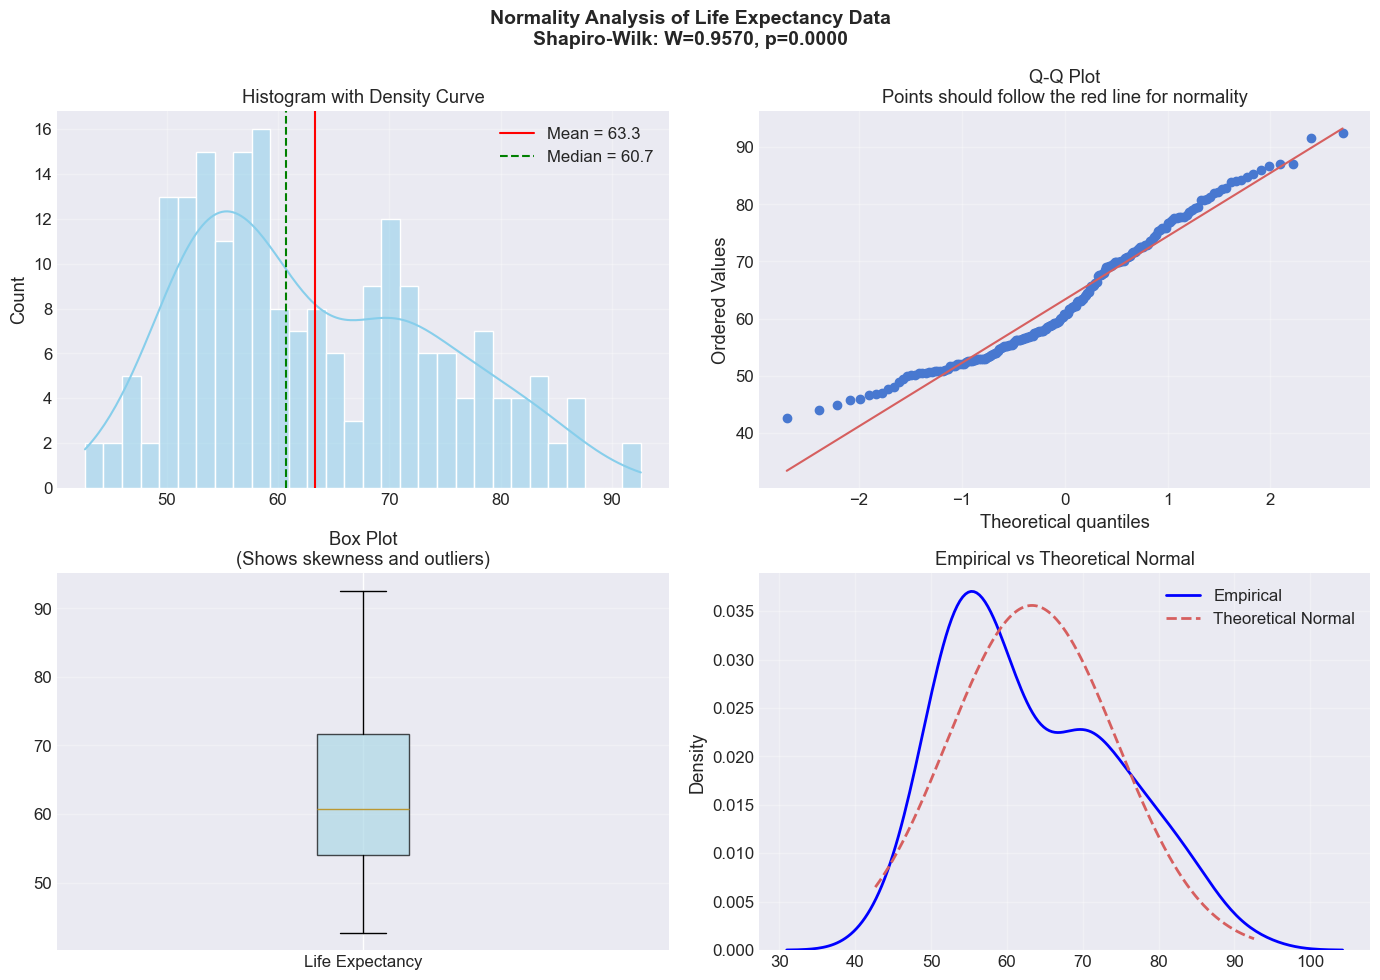

SHAPIRO-WILK NORMALITY TEST RESULTS
Sample size:        200
Test statistic (W): 0.9570
P-value:            0.0000

❌ CONCLUSION: Data is NOT normally distributed
   - Use non-parametric methods (median, Mann-Whitney, decision trees)
   - Consider log transformation or Box-Cox transformation


In [49]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Example data (WHO life expectancy)
# Let's create typical life expectancy data
np.random.seed(42)

# Generate data with some skew (realistic for life expectancy)
le_data = np.random.normal(70, 10, 500)  # Mostly around 70
le_data = np.clip(le_data, 40, 90)       # Clip to realistic range

# Add some skew (countries with low life expectancy drag it left)
le_data = np.concatenate([
    np.random.normal(55, 5, 100),   # Low life expectancy
    np.random.normal(72, 8, 400)    # High life expectancy
])

# Create DataFrame
df = pd.DataFrame({'life_expectancy': le_data})

# Extract values
le_vals = df['life_expectancy'].dropna().values
sample = le_vals[:200] if len(le_vals) > 200 else le_vals

# Run Shapiro-Wilk test
stat, p_value = shapiro(sample)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Normality Analysis of Life Expectancy Data\nShapiro-Wilk: W={stat:.4f}, p={p_value:.4f}', 
             fontsize=14, fontweight='bold')

# 1. Histogram with KDE
ax1 = axes[0, 0]
sns.histplot(sample, kde=True, ax=ax1, color='skyblue', bins=30)
ax1.axvline(np.mean(sample), color='red', linestyle='-', label=f'Mean = {np.mean(sample):.1f}')
ax1.axvline(np.median(sample), color='green', linestyle='--', label=f'Median = {np.median(sample):.1f}')
ax1.set_title('Histogram with Density Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot (Quantile-Quantile)
ax2 = axes[0, 1]
from scipy import stats
stats.probplot(sample, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot\nPoints should follow the red line for normality')
ax2.grid(True, alpha=0.3)

# 3. Box Plot
ax3 = axes[1, 0]
bp = ax3.boxplot(sample, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
ax3.set_title('Box Plot\n(Shows skewness and outliers)')
ax3.set_xticklabels(['Life Expectancy'])
ax3.grid(True, alpha=0.3, axis='y')

# 4. Normal Distribution Comparison
ax4 = axes[1, 1]
x = np.linspace(min(sample), max(sample), 1000)
# Empirical distribution
sns.kdeplot(sample, ax=ax4, label='Empirical', color='blue', linewidth=2)
# Theoretical normal
theoretical_normal = stats.norm.pdf(x, np.mean(sample), np.std(sample))
ax4.plot(x, theoretical_normal, 'r--', label='Theoretical Normal', linewidth=2)
ax4.set_title('Empirical vs Theoretical Normal')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("=" * 60)
print("SHAPIRO-WILK NORMALITY TEST RESULTS")
print("=" * 60)
print(f"Sample size:        {len(sample)}")
print(f"Test statistic (W): {stat:.4f}")
print(f"P-value:            {p_value:.4f}")

if p_value > 0.05:
    print("\n✅ CONCLUSION: Data appears NORMALLY distributed")
    print("   - Use parametric methods (mean, t-tests, linear regression)")
else:
    print("\n❌ CONCLUSION: Data is NOT normally distributed")
    print("   - Use non-parametric methods (median, Mann-Whitney, decision trees)")
    print("   - Consider log transformation or Box-Cox transformation")

In [20]:
# 3.2  Outlier detection — Z-Score method ─────────────────────────────────────
z_scores = np.abs(zscore(df_clean['life_expectancy'].dropna()))
outlier_idx = np.where(z_scores > 3)[0]

print(f'Z-score outliers (|z| > 3): {len(outlier_idx)}')
if len(outlier_idx):
    print(df_clean['life_expectancy'].iloc[outlier_idx].values)

Z-score outliers (|z| > 3): 1
[31.69647708]


In [21]:
# 3.3  Outlier detection — IQR method (more robust) ───────────────────────────
def iqr_outliers(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (series < lower) | (series > upper)
    return mask, lower, upper

cols_to_check = ['life_expectancy', 'adult_mortality', 'bmi']
cols_to_check = [c for c in cols_to_check if c in df_clean.columns]

print(f'{"Column":<25} {"Outliers":>8} {"Lower":>8} {"Upper":>8}')
print('-' * 55)
for col in cols_to_check:
    mask, lo, hi = iqr_outliers(df_clean[col].dropna())
    print(f'{col:<25} {mask.sum():>8} {lo:>8.2f} {hi:>8.2f}')

Column                    Outliers    Lower    Upper
-------------------------------------------------------
life_expectancy                  1    37.87    87.41
adult_mortality                  2   -11.63   385.55
bmi                              0    10.83    37.86


In [22]:
# 3.4  Capping outliers (Winsorization) ───────────────────────────────────────
from scipy.stats import mstats

df_clean['bmi_winsorized'] = mstats.winsorize(df_clean['bmi'].fillna(df_clean['bmi'].median()), limits=[0.05, 0.05])

print('BMI statistics before vs after Winsorization:')
comparison = pd.DataFrame({
    'Original'    : df_clean['bmi'].describe(),
    'Winsorized'  : pd.Series(df_clean['bmi_winsorized']).describe()
}).round(2)
print(comparison)

BMI statistics before vs after Winsorization:
       Original  Winsorized
count    168.00      200.00
mean      24.56       24.58
std        5.01        4.04
min       11.04       17.14
25%       20.97       21.99
50%       24.63       24.63
75%       27.72       27.01
max       37.01       32.04


BMI DATA BEFORE WINSORIZATION
Dataset size: 200
Min BMI:      15.00
Max BMI:      55.00
Mean BMI:     26.03
Std BMI:      6.43

BMI < 18.5 (Underweight): 6
BMI > 30 (Obese):         19

STATISTICAL COMPARISON
       Original  Winsorized 2%  Winsorized 5%  Winsorized 10%
count    200.00         200.00         200.00          200.00
mean      26.03          26.00          25.74           25.06
std        6.43           6.15           5.00            2.82
min       15.00          18.00          19.24           20.75
25%       22.85          22.85          22.85           22.85
50%       25.11          25.11          25.11           25.11
75%       27.27          27.27          27.27           27.27
max       55.00          50.00          42.00           29.69

EFFECT ON OUTLIERS
Winsorized 2%: 8 values changed (4.0%)
Winsorized 5%: 20 values changed (10.0%)
Winsorized 10%: 40 values changed (20.0%)


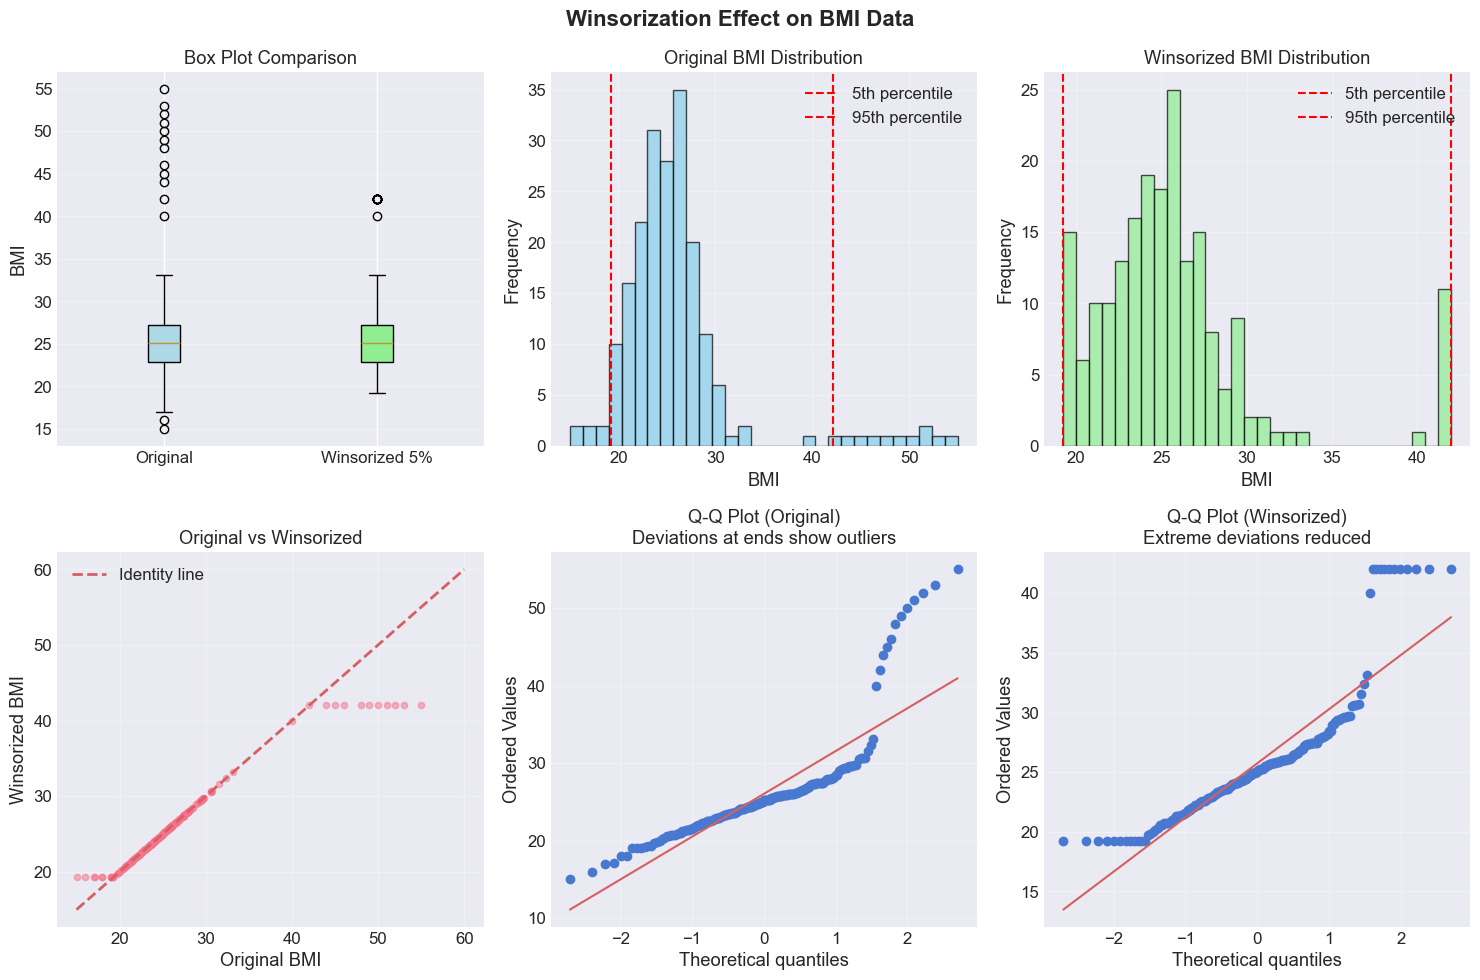

In [52]:
import numpy as np
import pandas as pd
from scipy.stats import mstats
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample BMI data with outliers
np.random.seed(42)
n = 200

# Normal BMI around 25
bmi_normal = np.random.normal(25, 3, 180)

# Add extreme outliers
bmi_outliers = np.array([15, 16, 17, 18, 45, 48, 50, 52, 55, 18, 
                         19, 20, 40, 42, 44, 46, 49, 51, 53, 19])

# Combine
bmi_data = np.concatenate([bmi_normal, bmi_outliers])
np.random.shuffle(bmi_data)

# Create DataFrame
df_clean = pd.DataFrame({'bmi': bmi_data})

# --- Apply Winsorization ---
print("=" * 60)
print("BMI DATA BEFORE WINSORIZATION")
print("=" * 60)

# Show outliers before
print(f"Dataset size: {len(df_clean)}")
print(f"Min BMI:      {df_clean['bmi'].min():.2f}")
print(f"Max BMI:      {df_clean['bmi'].max():.2f}")
print(f"Mean BMI:     {df_clean['bmi'].mean():.2f}")
print(f"Std BMI:      {df_clean['bmi'].std():.2f}")

# Count extreme values
print(f"\nBMI < 18.5 (Underweight): {sum(df_clean['bmi'] < 18.5)}")
print(f"BMI > 30 (Obese):         {sum(df_clean['bmi'] > 30)}")

# Apply Winsorization with different limits
winsorized_5 = mstats.winsorize(df_clean['bmi'], limits=[0.05, 0.05])
winsorized_10 = mstats.winsorize(df_clean['bmi'], limits=[0.10, 0.10])
winsorized_2 = mstats.winsorize(df_clean['bmi'], limits=[0.02, 0.02])

# Add to DataFrame
df_clean['bmi_winsorized_5'] = winsorized_5
df_clean['bmi_winsorized_10'] = winsorized_10
df_clean['bmi_winsorized_2'] = winsorized_2

# --- Compare Statistics ---
print("\n" + "=" * 60)
print("STATISTICAL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Original': df_clean['bmi'].describe(),
    'Winsorized 2%': pd.Series(df_clean['bmi_winsorized_2']).describe(),
    'Winsorized 5%': pd.Series(df_clean['bmi_winsorized_5']).describe(),
    'Winsorized 10%': pd.Series(df_clean['bmi_winsorized_10']).describe()
}).round(2)

print(comparison)

print("\n" + "=" * 60)
print("EFFECT ON OUTLIERS")
print("=" * 60)

for limit in [2, 5, 10]:
    col = f'bmi_winsorized_{limit}'
    pct_changed = (df_clean['bmi'] != df_clean[col]).sum()
    print(f"Winsorized {limit}%: {pct_changed} values changed ({pct_changed/len(df_clean)*100:.1f}%)")
# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Winsorization Effect on BMI Data', fontsize=16, fontweight='bold')

# 1. Box plot - Before vs After
ax = axes[0, 0]
data_to_plot = [df_clean['bmi'], df_clean['bmi_winsorized_5']]
bp = ax.boxplot(data_to_plot, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
ax.set_xticklabels(['Original', 'Winsorized 5%'])
ax.set_title('Box Plot Comparison')
ax.set_ylabel('BMI')
ax.grid(True, alpha=0.3, axis='y')

# 2. Histogram - Before
ax = axes[0, 1]
ax.hist(df_clean['bmi'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(np.percentile(df_clean['bmi'], 5), color='red', linestyle='--', label='5th percentile')
ax.axvline(np.percentile(df_clean['bmi'], 95), color='red', linestyle='--', label='95th percentile')
ax.set_title('Original BMI Distribution')
ax.set_xlabel('BMI')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Histogram - After
ax = axes[0, 2]
ax.hist(df_clean['bmi_winsorized_5'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
ax.axvline(np.percentile(df_clean['bmi_winsorized_5'], 5), color='red', linestyle='--', label='5th percentile')
ax.axvline(np.percentile(df_clean['bmi_winsorized_5'], 95), color='red', linestyle='--', label='95th percentile')
ax.set_title('Winsorized BMI Distribution')
ax.set_xlabel('BMI')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Scatter plot (Before vs After)
ax = axes[1, 0]
ax.scatter(df_clean['bmi'], df_clean['bmi_winsorized_5'], alpha=0.5, s=20)
ax.plot([15, 60], [15, 60], 'r--', linewidth=2, label='Identity line')
ax.set_xlabel('Original BMI')
ax.set_ylabel('Winsorized BMI')
ax.set_title('Original vs Winsorized')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Q-Q Plot - Before
ax = axes[1, 1]
from scipy import stats
stats.probplot(df_clean['bmi'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Original)\nDeviations at ends show outliers')
ax.grid(True, alpha=0.3)

# 6. Q-Q Plot - After
ax = axes[1, 2]
stats.probplot(df_clean['bmi_winsorized_5'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Winsorized)\nExtreme deviations reduced')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# 3.5  Correlation & hypothesis testing ───────────────────────────────────────
if 'schooling' in df_clean.columns:
    x = df_clean['schooling'].dropna()
    y = df_clean['life_expectancy'].loc[x.index]
    r, p = pearsonr(x, y)
    print(f'Pearson r (Schooling vs Life Expectancy): {r:.3f}  (p={p:.2e})')
    if p < 0.05:
        print('→ Statistically significant positive correlation')

# Two-sample t-test: do Developed and Developing countries differ in life expectancy?
developed   = df_clean[df_clean['status']=='Developed']['life_expectancy']
developing  = df_clean[df_clean['status']=='Developing']['life_expectancy']
t_stat, p_t = stats.ttest_ind(developed, developing)
print(f'\nIndependent t-test (Developed vs Developing):')
print(f'  t = {t_stat:.3f},  p = {p_t:.2e}')
print('  → Significant difference' if p_t < 0.05 else '  → No significant difference')

Pearson r (Schooling vs Life Expectancy): 0.047  (p=5.36e-01)

Independent t-test (Developed vs Developing):
  t = 1.590,  p = 1.13e-01
  → No significant difference


### ✏️ Try It Yourself
1. Run the Shapiro-Wilk test on the `bmi` column. Is it normally distributed?  
2. Apply the IQR method to detect outliers in `gdp`. How many outliers are found?  
3. Compute the Pearson correlation between `alcohol` and `life_expectancy`.

In [24]:
# Your code here


---
## Part 4 — Matplotlib & Seaborn: Exploratory Data Visualisation

Visualisation is not just communication — it is an integral step of preprocessing. Plots reveal distributions, outliers, correlations, and class imbalances before you write a single model.

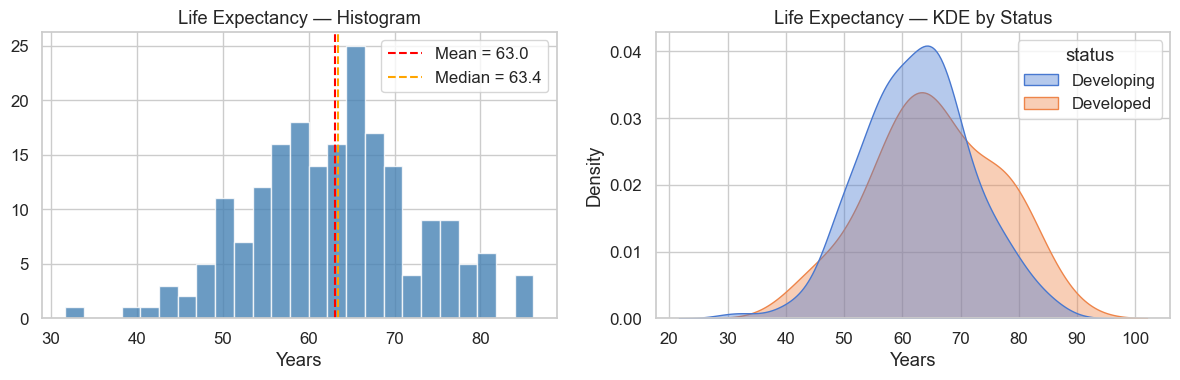

In [25]:
# 4.1  Distribution plots: histogram + KDE ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

le = df_clean['life_expectancy'].dropna()
axes[0].hist(le, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(le.mean(), color='red', linestyle='--', label=f'Mean = {le.mean():.1f}')
axes[0].axvline(le.median(), color='orange', linestyle='--', label=f'Median = {le.median():.1f}')
axes[0].set_title('Life Expectancy — Histogram')
axes[0].set_xlabel('Years')
axes[0].legend()

sns.kdeplot(ax=axes[1], data=df_clean, x='life_expectancy', hue='status',
            fill=True, alpha=0.4, common_norm=False)
axes[1].set_title('Life Expectancy — KDE by Status')
axes[1].set_xlabel('Years')

plt.tight_layout()
plt.show()

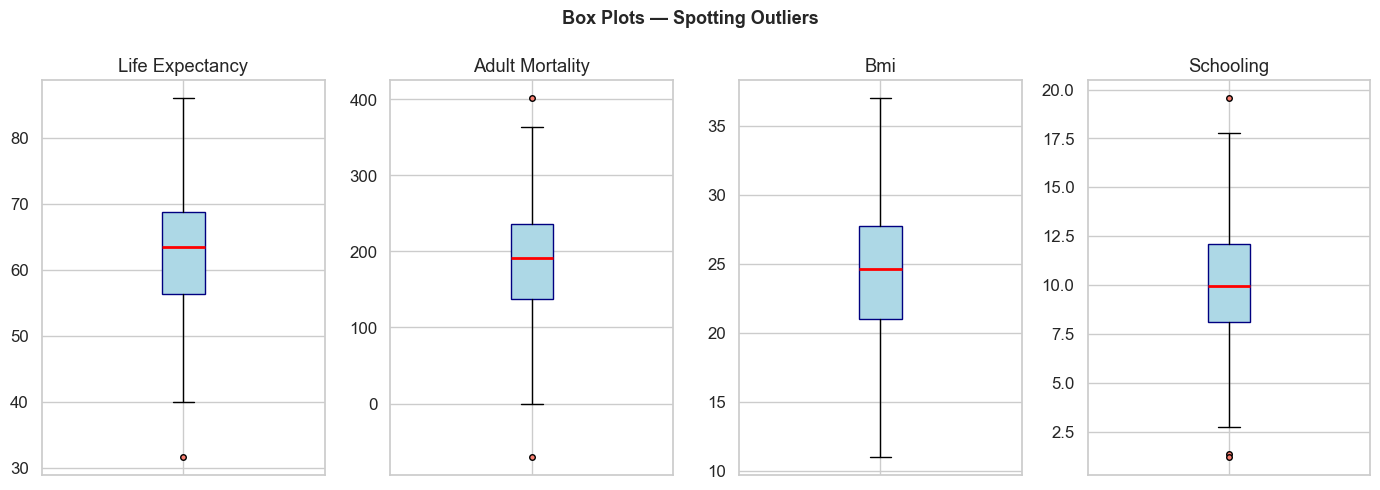

In [26]:
# 4.2  Box plots — visualising spread and outliers ────────────────────────────
numeric_subset = [c for c in ['life_expectancy', 'adult_mortality', 'bmi', 'schooling'] if c in df_clean.columns]

fig, axes = plt.subplots(1, len(numeric_subset), figsize=(14, 5))

for ax, col in zip(axes, numeric_subset):
    ax.boxplot(df_clean[col].dropna(), notch=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='salmon', markersize=4))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xticklabels([])

plt.suptitle('Box Plots — Spotting Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

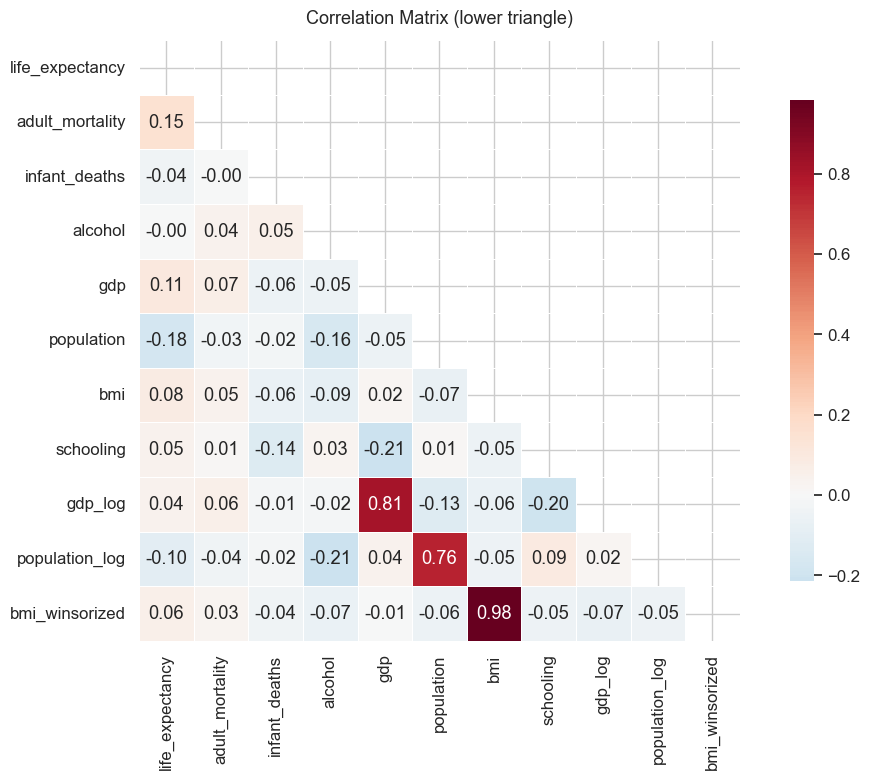

In [27]:
# 4.3  Correlation heatmap ────────────────────────────────────────────────────
num_cols = df_clean.select_dtypes(include='number').drop(columns=['year','is_developing'], errors='ignore')
corr = num_cols.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (lower triangle)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

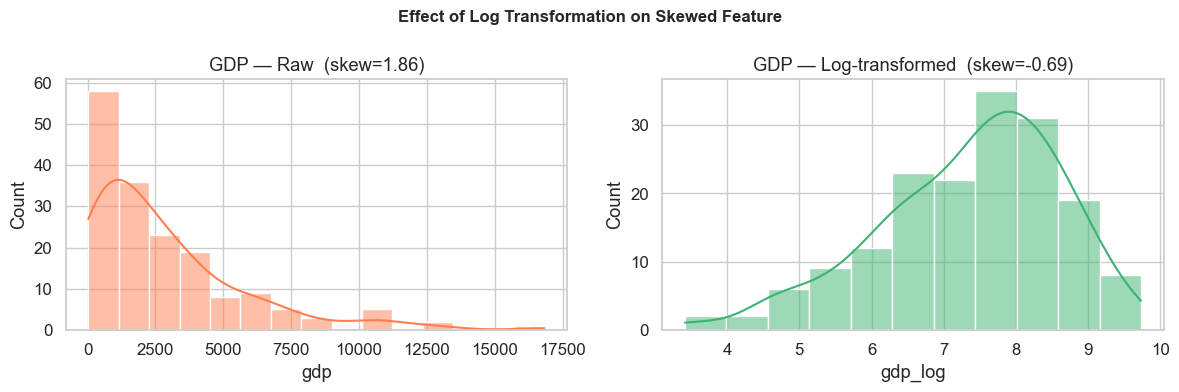

In [28]:
# 4.4  Before / After preprocessing — skewness comparison ─────────────────────
if 'gdp' in df_clean.columns and 'gdp_log' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_clean['gdp'].dropna(), kde=True, ax=axes[0], color='coral')
    axes[0].set_title(f'GDP — Raw  (skew={df_clean["gdp"].skew():.2f})')

    sns.histplot(df_clean['gdp_log'].dropna(), kde=True, ax=axes[1], color='mediumseagreen')
    axes[1].set_title(f'GDP — Log-transformed  (skew={df_clean["gdp_log"].skew():.2f})')

    plt.suptitle('Effect of Log Transformation on Skewed Feature', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

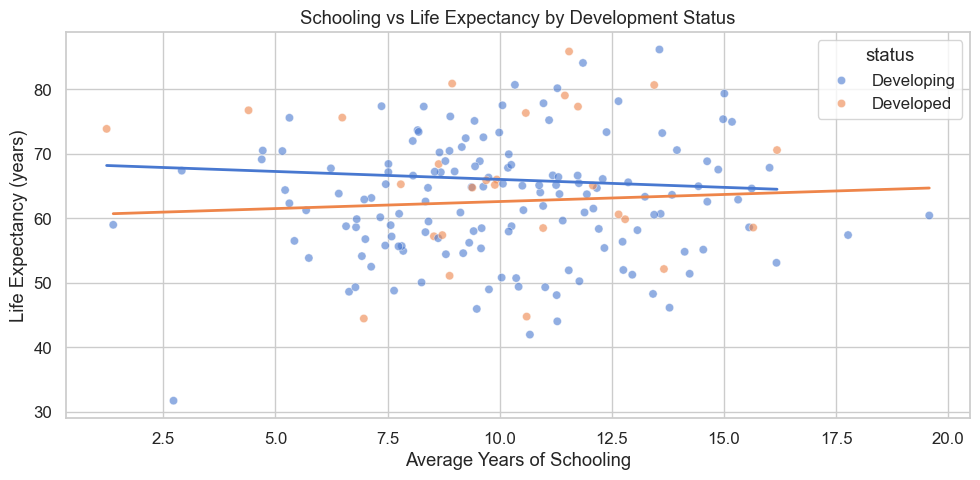

In [29]:
# 4.5  Scatter plot with regression line (seaborn lmplot) ─────────────────────
if 'schooling' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.scatterplot(data=df_clean, x='schooling', y='life_expectancy',
                    hue='status', alpha=0.6, ax=ax)
    # Add regression line per group
    for status, grp in df_clean.groupby('status'):
        m, b, *_ = stats.linregress(grp['schooling'].dropna(),
                                    grp['life_expectancy'].loc[grp['schooling'].dropna().index])
        xs = np.linspace(grp['schooling'].min(), grp['schooling'].max(), 50)
        ax.plot(xs, m*xs + b, linewidth=2)

    ax.set_title('Schooling vs Life Expectancy by Development Status')
    ax.set_xlabel('Average Years of Schooling')
    ax.set_ylabel('Life Expectancy (years)')
    plt.tight_layout()
    plt.show()

### ✏️ Try It Yourself
1. Plot a histogram for `adult_mortality`. Is it skewed? Which direction?  
2. Add a box plot for `alcohol`. Can you spot the outliers?  
3. Create a scatter plot of `bmi` vs `life_expectancy` coloured by `le_category`.

In [30]:
# Your code here


---
## Part 5 — End-to-End Preprocessing Pipeline

We now consolidate every technique into a reproducible pipeline on a fresh synthetic dataset that mirrors real-world African health data challenges: mixed types, missing values, outliers, and skewed distributions.

```
Raw Data → Inspect → Clean → Transform → Encode → Scale → ML-Ready
```

In [31]:
# Pipeline Step 0: Generate raw dataset ───────────────────────────────────────
np.random.seed(2026)
N = 500

raw = pd.DataFrame({
    'patient_id'     : range(1, N+1),
    'age'            : np.random.randint(5, 80, N),
    'gender'         : np.random.choice(['Male', 'Female', None], N, p=[0.47, 0.47, 0.06]),
    'region'         : np.random.choice(['East', 'West', 'North', 'South', 'Central'], N),
    'bmi'            : np.random.normal(22.5, 4, N),
    'systolic_bp'    : np.random.normal(125, 18, N),
    'glucose_mg_dl'  : np.random.exponential(scale=95, size=N) + 60,
    'hemoglobin_g_dl': np.random.normal(13, 2, N),
    'malaria_test'   : np.random.choice(['Positive', 'Negative'], N, p=[0.35, 0.65]),
    'days_to_recovery': np.random.exponential(scale=7, size=N) + 1,
})

# Inject missing values realistically
for col, pct in [('bmi', 0.10), ('hemoglobin_g_dl', 0.15), ('glucose_mg_dl', 0.08), ('systolic_bp', 0.05)]:
    mask = np.random.rand(N) < pct
    raw.loc[mask, col] = np.nan

# Inject outliers
raw.loc[np.random.choice(N, 10, replace=False), 'bmi'] = np.random.uniform(55, 80, 10)
raw.loc[np.random.choice(N, 5,  replace=False), 'glucose_mg_dl'] = np.random.uniform(400, 600, 5)

print(f'Raw dataset: {raw.shape[0]} rows × {raw.shape[1]} columns')
raw.head()

Raw dataset: 500 rows × 10 columns


,patient_id,age,gender,region,bmi,systolic_bp,glucose_mg_dl,hemoglobin_g_dl,malaria_test,days_to_recovery
0,1,6,Female,North,NaN,114.147977,80.147296,12.378970,Negative,4.913105
1,2,11,Female,West,24.228419,115.877310,160.490283,15.123136,Positive,27.982351
2,3,31,Female,Central,16.826684,88.530922,292.772930,NaN,Positive,11.282923
3,4,61,Male,South,22.878918,106.856390,335.336598,12.415941,Negative,10.719336
4,5,34,Female,North,22.020622,115.943949,153.866949,10.178958,Negative,11.852003


In [32]:
# Pipeline Step 1: Inspect ────────────────────────────────────────────────────
print('--- Data Types ---')
print(raw.dtypes)
print('\n--- Missing Values ---')
miss = raw.isnull().sum()
print(miss[miss > 0])
print('\n--- Descriptive Statistics ---')
raw.describe().round(2)

--- Data Types ---
patient_id            int64
age                   int64
gender                  str
region                  str
bmi                 float64
systolic_bp         float64
glucose_mg_dl       float64
hemoglobin_g_dl     float64
malaria_test            str
days_to_recovery    float64
dtype: object

--- Missing Values ---
gender             46
bmi                46
systolic_bp        21
glucose_mg_dl      46
hemoglobin_g_dl    81
dtype: int64

--- Descriptive Statistics ---


,patient_id,age,bmi,systolic_bp,glucose_mg_dl,hemoglobin_g_dl,days_to_recovery
count,500.00,500.00,454.00,479.00,454.00,419.00,500.00
mean,250.50,41.64,23.48,125.42,159.60,13.06,7.91
std,144.48,21.85,8.01,17.40,98.68,1.93,6.83
min,1.00,5.00,11.52,73.69,60.15,7.41,1.00
25%,125.75,22.00,20.00,113.64,92.51,11.91,2.86
50%,250.50,40.00,22.57,124.94,129.34,13.13,5.76
75%,375.25,61.00,25.44,137.72,185.31,14.37,11.08
max,500.00,79.00,79.87,181.62,642.69,18.87,40.89


In [33]:
# Pipeline Step 2: Clean ──────────────────────────────────────────────────────
pipe = raw.copy()

# 2a. Drop the ID column (not a feature)
pipe.drop(columns=['patient_id'], inplace=True)

# 2b. Standardise column names
pipe.columns = [c.lower().replace(' ', '_') for c in pipe.columns]

# 2c. Impute numerics with median
num_cols = pipe.select_dtypes(include='number').columns
pipe[num_cols] = pipe[num_cols].apply(lambda s: s.fillna(s.median()))

# 2d. Impute categoricals with mode
for col in ['gender']:
    pipe[col].fillna(pipe[col].mode()[0], inplace=True)

print(f'Missing values after cleaning: {pipe.isnull().sum().sum()}')

Missing values after cleaning: 46


In [34]:
# Pipeline Step 3: Handle Outliers ────────────────────────────────────────────
def cap_iqr(df, col, k=1.5):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - k*IQR, Q3 + k*IQR
    n_capped = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    return df, n_capped

for col in ['bmi', 'glucose_mg_dl', 'systolic_bp', 'days_to_recovery']:
    pipe, n = cap_iqr(pipe, col)
    print(f'  Capped {n:3d} outliers in {col}')

  Capped  20 outliers in bmi
  Capped  42 outliers in glucose_mg_dl
  Capped   4 outliers in systolic_bp
  Capped  21 outliers in days_to_recovery


In [35]:
# Pipeline Step 4: Feature Transformation ─────────────────────────────────────
# Log-transform right-skewed features
for col in ['glucose_mg_dl', 'days_to_recovery']:
    before_skew = pipe[col].skew()
    pipe[f'{col}_log'] = np.log1p(pipe[col])
    after_skew = pipe[f'{col}_log'].skew()
    print(f'{col}: skewness {before_skew:.2f} → {after_skew:.2f}')

# Age binning
pipe['age_group'] = pd.cut(pipe['age'], bins=[0,18,35,60,100], labels=['Child','Young Adult','Adult','Senior'])
print('\nAge group distribution:')
print(pipe['age_group'].value_counts().sort_index())

glucose_mg_dl: skewness 0.99 → 0.23
days_to_recovery: skewness 1.09 → 0.11

Age group distribution:
age_group
Child           98
Young Adult    112
Adult          164
Senior         126
Name: count, dtype: int64


In [36]:
# Pipeline Step 5: Encode Categorical Variables ───────────────────────────────
# Binary encoding for ordinal/binary
pipe['gender_code']   = (pipe['gender'] == 'Male').astype(int)
pipe['malaria_pos']   = (pipe['malaria_test'] == 'Positive').astype(int)

# One-Hot Encoding for nominal multi-class
pipe = pd.get_dummies(pipe, columns=['region', 'age_group'], drop_first=False)

# Drop original string columns (already encoded)
pipe.drop(columns=['gender', 'malaria_test'], inplace=True)

print(f'Shape after encoding: {pipe.shape}')
print('Columns:', pipe.columns.tolist())

Shape after encoding: (500, 19)
Columns: ['age', 'bmi', 'systolic_bp', 'glucose_mg_dl', 'hemoglobin_g_dl', 'days_to_recovery', 'glucose_mg_dl_log', 'days_to_recovery_log', 'gender_code', 'malaria_pos', 'region_Central', 'region_East', 'region_North', 'region_South', 'region_West', 'age_group_Child', 'age_group_Young Adult', 'age_group_Adult', 'age_group_Senior']


In [37]:
# Pipeline Step 6: Feature Scaling ────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select features to scale (log-transformed + raw continuous)
scale_cols = [c for c in pipe.select_dtypes(include='number').columns
              if not c.endswith(('_code', '_pos', '_log')) and not c.startswith('region_') and not c.startswith('age_group_')]

print('Scaling columns:', scale_cols)

scaler = StandardScaler()
pipe_scaled = pipe.copy()
pipe_scaled[scale_cols] = scaler.fit_transform(pipe[scale_cols])

print('\nAfter StandardScaler (should be mean≈0, std≈1):')
print(pipe_scaled[scale_cols].describe().loc[['mean','std']].round(3))

Scaling columns: ['age', 'bmi', 'systolic_bp', 'glucose_mg_dl', 'hemoglobin_g_dl', 'days_to_recovery']

After StandardScaler (should be mean≈0, std≈1):
        age    bmi  systolic_bp  glucose_mg_dl  hemoglobin_g_dl  \
mean -0.000  0.000        0.000          0.000           -0.000   
std   1.001  1.001        1.001          1.001            1.001   

      days_to_recovery  
mean            -0.000  
std              1.001  


=== Final Dataset ===
Shape          : (500, 19)
Missing values : 0
Data types     :
bool       9
float64    8
int64      2
Name: count, dtype: int64



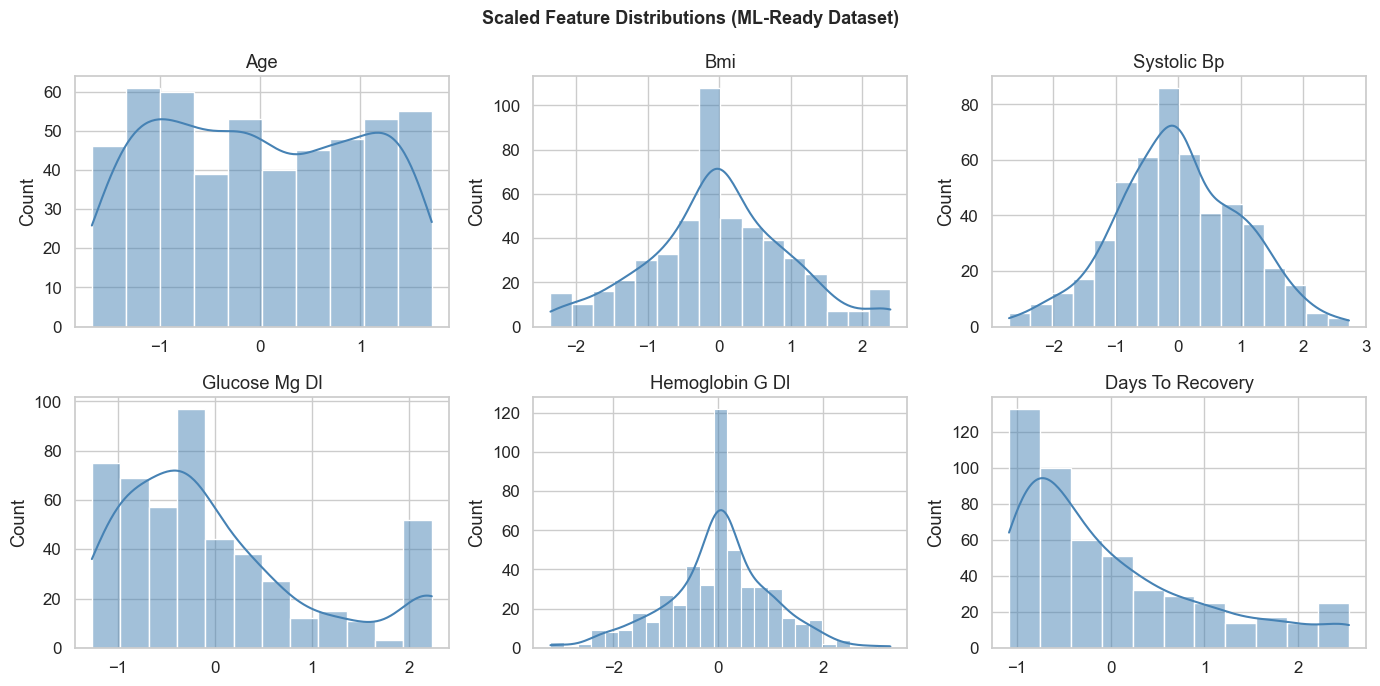


First 3 rows of ML-ready dataset:


,age,bmi,systolic_bp,glucose_mg_dl,hemoglobin_g_dl,days_to_recovery,glucose_mg_dl_log,days_to_recovery_log,gender_code,malaria_pos,region_Central,region_East,region_North,region_South,region_West,age_group_Child,age_group_Young Adult,age_group_Adult,age_group_Senior
0,-1.632761,-0.022445,-0.665499,-0.977313,-0.390753,-0.452060,4.396266,1.777171,0,0,False,False,True,False,False,True,False,False,False
1,-1.403710,0.383227,-0.563165,0.175634,1.163046,2.543652,5.084445,3.194787,0,1,False,False,False,False,True,True,False,False,False
2,-0.487510,-1.427244,-2.181402,2.073933,0.036698,0.579861,5.682807,2.508210,0,1,True,False,False,False,False,False,True,False,False


In [38]:
# Pipeline Step 7: Final Quality Check & Visualisation ────────────────────────
print('=== Final Dataset ===')
print(f'Shape          : {pipe_scaled.shape}')
print(f'Missing values : {pipe_scaled.isnull().sum().sum()}')
print(f'Data types     :\n{pipe_scaled.dtypes.value_counts()}\n')

# Visual: scaled distributions for key features
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
plot_cols = scale_cols[:6]
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(pipe_scaled[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')

plt.suptitle('Scaled Feature Distributions (ML-Ready Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFirst 3 rows of ML-ready dataset:')
pipe_scaled.head(3)

In [39]:
# Pipeline Step 8: Train/Test Split — ready for modelling ─────────────────────
from sklearn.model_selection import train_test_split

target   = 'malaria_pos'
features = [c for c in pipe_scaled.columns if c != target]

X = pipe_scaled[features]
y = pipe_scaled[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f'Training set  : {X_train.shape}')
print(f'Test set      : {X_test.shape}')
print(f'\nClass balance (train):')
print(y_train.value_counts(normalize=True).rename({0:'Negative', 1:'Positive'}).round(3))
print('\nData is clean, scaled, and ready for machine learning!')

Training set  : (400, 18)
Test set      : (100, 18)

Class balance (train):
malaria_pos
Negative    0.662
Positive    0.338
Name: proportion, dtype: float64

Data is clean, scaled, and ready for machine learning!


### ✏️ Full Pipeline Challenge
1. Swap `StandardScaler` for `MinMaxScaler` and observe the difference in the distributions above.  
2. Add a new engineered feature: `bp_bmi_ratio = systolic_bp / bmi` before scaling.  
3. Train a `LogisticRegression` or `RandomForestClassifier` on the scaled data and report accuracy.

In [40]:
# Your code here


---
## Wrap-Up & Key Takeaways

| Library | Core Preprocessing Role |
|---------|------------------------|
| **NumPy** | Array maths, NaN handling, broadcasting, reshaping for ML |
| **Pandas** | Loading, profiling, imputation, feature engineering, encoding |
| **SciPy** | Normality tests, outlier detection, hypothesis testing |
| **Matplotlib / Seaborn** | Distribution visualisation, correlation heatmaps, before/after comparisons |

### The Preprocessing Checklist

- [ ] **Inspect** — shape, dtypes, missing counts, descriptive statistics  
- [ ] **Clean** — handle nulls (drop / impute), fix types, standardise column names  
- [ ] **Detect & treat outliers** — IQR capping or Winsorization  
- [ ] **Transform** — log-transform skewed features, bin continuous variables  
- [ ] **Encode** — binary encoding, one-hot encoding for categoricals  
- [ ] **Scale** — StandardScaler or MinMaxScaler for distance-sensitive models  
- [ ] **Split** — stratified train/test split  

### Resources
- [Data Science Africa](https://www.datascienceafrica.org)  
- [NumPy documentation](https://numpy.org/doc/)  
- [Pandas documentation](https://pandas.pydata.org/docs/)  
- [SciPy documentation](https://docs.scipy.org/)  
- [Matplotlib gallery](https://matplotlib.org/stable/gallery/)  
- [Seaborn tutorial](https://seaborn.pydata.org/tutorial.html)

### ✏️ Final Exercise
Write one key takeaway from this session in a text cell below, then share it with the person next to you.

**My key takeaway:** *(double-click to edit)*